# Intro figure

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ['JAX_ENABLE_X64'] = '1'

cache_path = "../../cache/"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import corc
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram
from collections import Counter
import sklearn
import studenttmixture
import corc.mixture
import itertools
import corc.visualization
import corc.tmm_plots
import corc.utils

In [3]:
dataset_filename = 'intro_figure.pickle'
with open(cache_path + dataset_filename, 'rb') as f:
    X, y = pickle.load(f)

y = np.array(y,dtype=int)

In [4]:
model_filename = "intro_figure_TMM-NEB.pickle"
with open(cache_path + model_filename, 'rb') as f:
    tmm_model = pickle.load(f)

y_pred = np.array(tmm_model.predict(X),dtype=int)

In [5]:

edges=False
pairs = tmm_model.get_merged_pairs(
    target_num_classes=len(set(y)), only_mst_edges=True
)

pairs2 = tmm_model.get_merged_pairs(
    target_num_classes=3, only_mst_edges=True
)

In [6]:
original_linkage = []
new_clusters = {}
amount_of_points = dict(Counter(tmm_model.predict(X).tolist()))
counting = len(amount_of_points) 
prev = []
start_num = 0

initial_num_clusters = len(tmm_model.mixture_model.weights)
for i in range(initial_num_clusters-1, 0, -1):
    cur = tmm_model.get_merged_pairs(
            target_num_classes=i, only_mst_edges=True
        )
    new_edge = list(set(cur).difference(set(prev)))
    print(new_edge)
    assert len(new_edge) == 1
    new_edge = new_edge[0]
    prev = cur
    new_amount = 0
    
    loc = new_edge[0]
    while loc in new_clusters:
        loc = new_clusters[loc]
    new_amount += amount_of_points[loc]
    new_clusters[loc] = counting
    from_ = loc
    
    loc = new_edge[1]
    while loc in new_clusters:
        loc = new_clusters[loc]
    new_amount += amount_of_points[loc]
    new_clusters[loc] = counting
    to = loc
    

    original_linkage.append([from_, to, 
                    max(-tmm_model.adjacency_[new_edge[0], new_edge[1]], 0.01), 
                    new_amount])

    amount_of_points[counting] = new_amount
    counting += 1

[(7, 13)]
[(4, 7)]
[(1, 12)]
[(5, 10)]
[(2, 9)]
[(3, 6)]
[(6, 14)]
[(0, 8)]
[(0, 11)]
[(10, 12)]
[(7, 8)]
[(3, 12)]
[(6, 11)]
[(2, 8)]


In [7]:
# adjusted from corc.utils
def plot_field(
    data_X,
    mixture_model,
    levels=20,
    paths=None,  # storage of all paths
    selection=None,  # selection which paths to plot
    save_path=None,
    axis=None,
    plot_points=True,  # whether data_X is plotted
    transformed_points=None,
    grid_resolution=128,
    plot_ids=True,
    markersize=3
):
    """Plots the TMM/GMM field and the optimized paths (if available).
    selection: selects which paths are included in the plot, by default, all paths are included.
      other typical options: MST through selection=zip(mst.row,mst.col) and individuals via e.g. [(0,1), (3,4)]

    """
    locations = corc.utils.mixture_center_locations(mixture_model)
    n_components = len(locations)

    
    transformed_points = data_X

    # plot the energy landscape if possible
    if data_X.shape[-1] == 2:
        mixture_model.plot_energy_landscape(
            data_X,
            axis=axis,
            levels=levels,
        )

    # plot the raw data
    if plot_points:
        axis.scatter(
            transformed_points[:, 0], transformed_points[:, 1], s=markersize
        )

    # plot cluster centers and IDs
    axis.scatter(
        locations[:, 0],
        locations[:, 1],
        color="black",
        marker="X",
        s=markersize*2,
    )
    if plot_ids:
        for i, location in enumerate(locations):
            y_min, y_max = axis.get_ylim()
            scale = y_max - y_min
            if i == 10:
                axis.text(location[0]-0.2, location[1]+0.1, f"{i}", color="black", fontsize=6)
            elif i == 8 or i == 3 or i==9:
                axis.text(location[0]-0.1, location[1]-0.4, f"{i}", color="black", fontsize=6)
            else:
                axis.text(location[0]+0.1, location[1]+0.1, f"{i}", color="black", fontsize=6)
                
    # plot paths between centers (by default: all)
    if paths is not None:
        if selection is None:
            selection = list(itertools.combinations(range(n_components), r=2))
        for i, j in selection:
            # path = paths[(i, j)]
            # axis.plot(path[:, 0], path[:, 1], lw=2, alpha=0.5, color="black")
            start = locations[i]
            end = locations[j]
            axis.plot(
                *zip(start, end),
                color="black",
                alpha=1,
            )


In [8]:
custom_colors = [
    corc.visualization.COLOR_DICT['petrol'],
    corc.visualization.COLOR_DICT['green'],
    corc.visualization.COLOR_DICT['red'],
    corc.visualization.COLOR_DICT['orange'],
    corc.visualization.COLOR_DICT['purple'],
    corc.visualization.COLOR_DICT['turquoise'],
    # 'steelblue', 'sandybrown', 
    #              # 'red', 
    #              'darkturquoise', 'tomato', 
    #              'mediumslateblue', 
    #              'firebrick', 'magenta', 'olive', 'limegreen', 
]
from scipy.cluster.hierarchy import set_link_color_palette
set_link_color_palette(custom_colors) # this will be left-to-right

cluster_colors = [
    corc.visualization.COLOR_DICT['turquoise'], # 0
    corc.visualization.COLOR_DICT['orange'], # 1 
    corc.visualization.COLOR_DICT['petrol'], # 2
    corc.visualization.COLOR_DICT['green'], # 3
    corc.visualization.COLOR_DICT['purple'], # 4
    corc.visualization.COLOR_DICT['red'],  # 5
    corc.visualization.COLOR_DICT['green_50'], # 6
    corc.visualization.COLOR_DICT['purple_75'], # 7
    corc.visualization.COLOR_DICT['turquoise_75'], # 8
    corc.visualization.COLOR_DICT['petrol_50'], # 9
    corc.visualization.COLOR_DICT['red_50'], # 10
    corc.visualization.COLOR_DICT['turquoise_50'], # 11
    corc.visualization.COLOR_DICT['orange_50'], # 12
    corc.visualization.COLOR_DICT['purple_50'], # 13
    corc.visualization.COLOR_DICT['green_75'], # 14
]


cluster_colors2 = [
    corc.visualization.COLOR_DICT['purple'], # 0
    corc.visualization.COLOR_DICT['yellow'], # 1 
    corc.visualization.COLOR_DICT['petrol'], # 2
    corc.visualization.COLOR_DICT['green'], # 3
    corc.visualization.COLOR_DICT['turquoise'], # 4
    corc.visualization.COLOR_DICT['red'],  # 5
    corc.visualization.COLOR_DICT['green'], # 6
    corc.visualization.COLOR_DICT['green'], # 7
    corc.visualization.COLOR_DICT['purple'], # 8
    corc.visualization.COLOR_DICT['yellow'], # 9
    corc.visualization.COLOR_DICT['petrol'], # 10
    corc.visualization.COLOR_DICT['turquoise'], # 11
    corc.visualization.COLOR_DICT['yellow'], # 12
    corc.visualization.COLOR_DICT['purple'], # 13
    corc.visualization.COLOR_DICT['red'], # 14
]

y_colors = [cluster_colors[i] for i in y_pred]


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from matplotlib import cm

def plot_energy_landscape_thresholding(
    mixture_model,
    data_X,  # For boundary computation
    threshold,
    grid_resolution=128,
    axis=None,
    levels=20,  # Default number of levels
    kwargs={}
):
    if axis is None:
        axis = plt.gca()

    # Grid coordinates
    margin = 1
    x_grid = np.linspace(
        data_X[:, 0].min() - margin, data_X[:, 0].max() + margin, grid_resolution
    )
    y_grid = np.linspace(
        data_X[:, 1].min() - margin, data_X[:, 1].max() + margin, grid_resolution
    )
    XY = np.stack(np.meshgrid(x_grid, y_grid), -1)

    # Get scores for the grid values
    mm_probs = mixture_model.score_samples(XY.reshape(-1, 2)).reshape(
        grid_resolution, grid_resolution
    )
    mm_probs = np.clip(mm_probs, None, 0)  # Clip values at 0

    # Determine contour levels using MaxNLocator
    locator = MaxNLocator(nbins=levels)
    contour_levels = locator.tick_values(np.min(mm_probs), np.max(mm_probs))
    
    # Define number of levels below and above the threshold
    num_levels_below = np.sum(contour_levels <= threshold)
    num_levels_above = len(contour_levels) - num_levels_below

    # Create coolwarm colormap for levels above the threshold with custom alpha
    cmap_coolwarm = cm.get_cmap('coolwarm', levels)
    coolwarm_colors = cmap_coolwarm(np.linspace(0, 1, levels))[-num_levels_above-7:]
    coolwarm_colors[:, -1] = 0.9  # Alpha for coolwarm

    # Use only the coolwarm colormap for levels above the threshold
    levels_above_threshold = contour_levels[contour_levels > threshold]
    cmap_combined = LinearSegmentedColormap.from_list('custom_colormap', coolwarm_colors)

    # Plot with modified colormap for levels above threshold
    axis.contourf(
        x_grid,
        y_grid,
        mm_probs,
        levels=levels_above_threshold,
        cmap=cmap_combined,
        zorder=-10,
        **kwargs
    )
    axis.contour(
        x_grid,
        y_grid,
        mm_probs,
        levels=[threshold],
        colors="#612158",
        linewidths=2.5,  # Set the thickness of the line
        zorder=-5  # Specifies the drawing order
    )
def plot_threshold_landscape(ax, tmm_model, data_X, threshold, target_number_classes):
    ax.set_facecolor('#F0F0F0')
    plot_energy_landscape_thresholding(tmm_model.mixture_model, data_X, threshold=threshold, axis=ax, levels=50)
    y_pred = tmm_model.predict_with_target(data_X, target_number_classes=target_number_classes)
    ax.scatter(data_X[:, 0], data_X[:, 1], c="black", s=4)
    ax.scatter(data_X[:, 0], data_X[:, 1], c=y_pred, s=4)
    ax.set_xticks([])  # Hides the x-axis ticks
    ax.set_yticks([])  # Hides the y-axis ticks
    ax.set_frame_on(False)  # Removes the frame


In [10]:
def plot_ground_truth(ax, letter="A"):
    ax.set_axis_off()

    covs = np.array([np.diag((1,1))]).repeat(6, axis=0)*0.8
    mixture_model = corc.mixture.GaussianMixtureModel(
        centers=np.array([(-5,5.5),(-5,1),(-5,-3.5),(4,-5),(7,-2),(5,8)]),
        covs=covs,
        weights=[1,1,1,1,1,1]
    )
    mixture_model.plot_energy_landscape(
        data_X=X,
        axis=ax,levels=60, 
        kwargs=dict(vmax=15)
    )
    ax.scatter(X[:,0],X[:,1],s=1,c=corc.visualization.COLOR_DICT['blue'])
    ax.text(0.03, 0.9, letter, transform=ax.transAxes, 
                size=10, weight='bold')

In [11]:
def plot_clustering_result(ax, letter="B", edges=True, MARKERSIZE=6, FONTSIZE=7):
    ax.set_axis_off()

    # background
    tmm_model.mixture_model.plot_energy_landscape(
        data_X=X,
        levels=60,
        axis=ax,
    )
    # points
    ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=MARKERSIZE/2, alpha=1)

    # centers
    centers = tmm_model.mixture_model.centers
    ax.scatter(centers[:, 0], centers[:, 1], c="black", marker="x", s=2*MARKERSIZE,zorder=20)

    # numbers for clusters
    offsets = { 
        0: (0.9,0),
        2: (0.7,-.2),
        3: (-.5,-.3),
        4: (0.6,-1),
        5: (0.6,-0.6),
        6: (0.4,-.9),
        7: (0.5,-.8),
        8: (0.3,-1.3),
        9: (0.2,-1.1),
        10: (0.2,.5),
        12: (0.3,-1.1),
        13: (-0.5,.3),
    }
    for i, center in enumerate(centers):
        if i in offsets.keys():
            offset = offsets[i]
        else:
            offset = (0.2,0.4)
        ax.text(center[0]+offset[0], center[1]+offset[1], f"{i}", color="white", fontsize=FONTSIZE,weight="bold",ha='center',zorder=100)
        ax.text(center[0]+offset[0], center[1]+offset[1], f"{i}", color="black", fontsize=FONTSIZE,ha='center', zorder=101)

    # edges
    pairs2 = tmm_model.get_merged_pairs(
        target_num_classes=6, only_mst_edges=True
    )
    pairs2 += [(7,0),(11,6),(5,14),(10,12),(13,9)]
    # pairs2 += [(7,13),(11,10),(9,14),(5,6),(0,4)]
    if edges: 
        for pair in pairs2:
            if pair in tmm_model.paths_.keys():
                path = tmm_model.paths_[(pair[0], pair[1])]
                ax.plot(path[:, 0], 
                        path[:, 1], 
                        alpha=.9, 
                        color=corc.visualization.COLOR_DICT["black_50"],
                        lw=30/(tmm_model.adjacency_[pair[0], pair[1]])**2
                )

    # marker B
    ax.text(0.03, 0.9, letter, transform=ax.transAxes, 
                size=10, weight='bold')

In [12]:
def plot_threshold_and_cluster_numbers(ax, letter, MARKERSIZE, FONTSIZE):
    threshold_dict, _ = tmm_model.get_thresholds_and_cluster_numbers()
    xs = sorted(list(threshold_dict.keys()))[::-1]
    ys  = [-threshold_dict[x] for x in xs]
    ax.plot(xs, ys, marker="o", markersize=MARKERSIZE/2, lw=0)
    ax.set_xlabel("Number of clusters", fontsize=FONTSIZE, labelpad=1)
    ax.set_ylabel("Threshold", fontsize=FONTSIZE, labelpad=1)
    # plt.title("Clusters")

    # arrow with text
    ax.arrow(15.65, 0.5, -8.5, 0, head_width=.4, head_length=0.7, overhang=1)
    ax.text(11, 1.1, 'merging clusters', ha='center', fontsize=FONTSIZE)

    # vertical lines
    ax.axvline(x=3, color=corc.visualization.COLOR_DICT['red'], linestyle='--', lw=.8)
    ax.axvline(x=6, color=corc.visualization.COLOR_DICT['red'], linestyle='--', lw=.8)
    ax.text(6,-2.15,"6", fontsize=FONTSIZE,ha='center',c=corc.visualization.COLOR_DICT['red'], weight='bold')
    ax.text(3,-2.15,"3", fontsize=FONTSIZE,ha='center',c=corc.visualization.COLOR_DICT['red'], weight='bold')

    ax.grid(axis='y', alpha=0.7)
    ax.invert_xaxis()
    corc.visualization.remove_border(ax)
    ax.tick_params(axis='both', labelsize=FONTSIZE)
    # ax.tick_params(axis='x', which='major', pad=0,)

    ax.text(-0.25, 0.9, letter, transform=ax.transAxes, 
                size=10, weight='bold')

In [13]:
def plot_dendrogram(ax, letter, FONTSIZE):
    corc.visualization.remove_border(ax)
    ax.grid(axis='y', alpha=0.7)
    # ax.set_yticklabels([])
    # ax.set_yticks([])

    dendrogram(original_linkage, color_threshold=5, ax=ax)
    ax.tick_params(axis='x', which='major', pad=-3,rotation=60)
    ax.set_xlabel("Cluster ID (before merging)", labelpad=4, fontsize=FONTSIZE)
    ax.tick_params(axis='both', labelsize=FONTSIZE)
    ax.set_ylabel('Threshold', fontsize=FONTSIZE, labelpad=1)
    ax.text(-0.25, 0.9, letter, transform=ax.transAxes, 
                size=10, weight='bold')

/mnt/lustre-grete/tmp/u14643/ipykernel_398352/3614780514.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


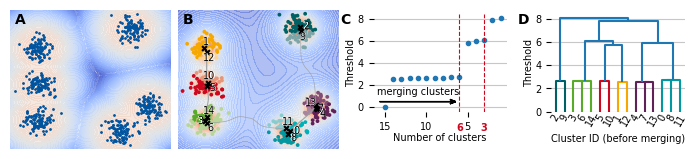

In [ ]:
# one line version of the above plot.

edges=True
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(7, 1.6))
# fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(7, 1.6))
axes = axes.flatten()

MARKERSIZE = 6
FONTSIZE = 7
############### Plot A ###############
# Generating distribution
ax = axes[0]
ax.set_axis_off()
# create new axis to actually fill the available space
ax = plt.axes([0.01, 0.06, 0.23, .87])  # [left, bottom, width, height]
plot_ground_truth(ax,letter="A")

############### Plot B ###############
ax = axes[1]
ax.set_axis_off()
ax = plt.axes([0.25, 0.06, 0.23, .87])  # [left, bottom, width, height]
plot_clustering_result(ax, letter="B", edges=edges, MARKERSIZE=MARKERSIZE, FONTSIZE=FONTSIZE)

############### Plot C ###############
ax = axes[2]
plot_threshold_and_cluster_numbers(ax, letter="C", MARKERSIZE=MARKERSIZE, FONTSIZE=FONTSIZE)

############### Plot D ###############
ax = axes[3]
plot_dendrogram(ax, letter="D", FONTSIZE=FONTSIZE)

plt.tight_layout()

if edges:
    figure_path = "../../figures/intro_figure_edges.png"
    # figure_path = "../../figures/intro_figure_edges.pdf"
else:
    figure_path = "../../figures/intro_figure.pdf"
plt.savefig(
    # f"{pre}figures/claude_neb_join_strategies_{dataset_name}_seed_{seed}_n_components_{n_components}.pdf",
    figure_path, bbox_inches='tight', pad_inches=0, dpi=600)

# code to create data and model (do not run!)

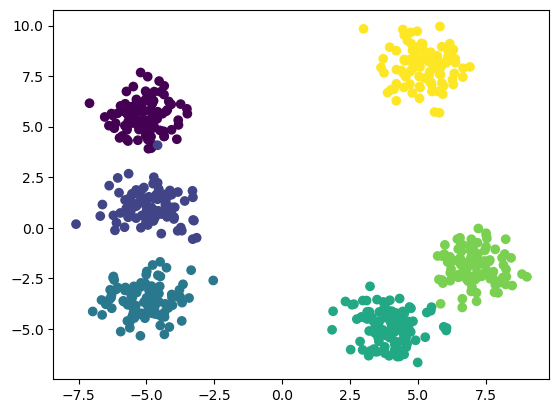

In [41]:
def vec2d_from_angle(angle: float | np.ndarray) -> np.ndarray:
    """
    Convert an angle to a 2D vector
    """
    return np.stack([np.cos(angle), np.sin(angle)], -1)

def create_intro_dataset() -> tuple[np.ndarray, np.ndarray]:
    """
    Simulating six clusters with different push apart degrees and variances,
    example dataset 10 from the R package clusterlab.
    Used in "Sparse clusterability: testing for cluster structure in high
    dimensions" by Laborde et al. (2023).
    """
    # see the 'clusterlab_dataset2' for comments explaining the code
    cs = vec2d_from_angle(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    xs = []
    ys = []

    for i, (center, spread) in enumerate(
        [
            ((-5,5.5),1),
            ((-5,1),1),
            ((-5,-3.5),1),
            ((4,-5),1),
            ((7,-2),1),
            ((5,8),1),
        ]
    ):
        xs.append(np.random.normal(size=(100, 2)) * spread *.8 + center)
        ys.append(np.zeros(100) + i)

    # for i, (c, s, a) in enumerate(

    #     zip(
    #         cs,
    #         [0.5, 1.0, 1.5, 1.75, 2.0, 2.25, 2.25],
    #         [0.5, 1.0, 1.5, 1.75, 1.85, 1.95, 2.05],
    #     )
    # ):
    #     xs.append(np.random.normal(size=(50, 2)) * s + c * 9 * a)
    #     ys.append(np.zeros(50) + i)

    xs = np.vstack(xs)
    ys = np.concatenate(ys)
    return xs, ys

# X,y = create_intro_dataset()



In [40]:
with open(cache_path + dataset_filename, 'wb') as f:
    pickle.dump((X, y), f)

In [65]:
import corc.graph_metrics
import corc.graph_metrics.neb


tmm_model = corc.graph_metrics.neb.NEB(
    data=X,
    labels=y,
    n_components=15,
    optimization_iterations=250,
    min_cluster_size=8,
    max_elongation=100,
    tmm_regularization=1e-2,
)
tmm_model.fit(X)

[[43  3]
 [39  1]
 [72  1]
 [14  6]
 [31  3]
 [52  3]
 [23  4]
 [63  2]
 [22  2]
 [25  2]
 [28  2]
 [68  1]
 [37  1]
 [36  2]
 [47  3]]
After filtering 15 components, we are left with 15 components


tmm: 100%|██████████| 150/150 [02:52<00:00,  1.15s/it]


In [113]:
model_filename = "intro_figure_TMM-NEB.pickle"
with open(cache_path + model_filename, 'wb') as f:
    pickle.dump(tmm_model, f)

In [ ]:
with open(f'{cache_path}clusterlab10_TMM-NEB.pickle', 'rb') as f:
    tmm_model = varied = pickle.load(f)

X, y, transformed_points = corc.utils.load_dataset(
    # dataset_name='varied', 
    # dataset_name='blobs',
    dataset_name='clusterlab10', 
    cache_path=cache_path
)

pairs = varied.get_merged_pairs(
    target_num_classes=len(set(y)), only_mst_edges=True
)